In [1]:
install.packages("igraph", repos = "https://cloud.r-project.org")
library(igraph)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [2]:
edges <- data.frame(
  From = c("A", "A", "A", "B", "B", "C", "C", "D", "E", "F", "G", "H"),
  To   = c("B", "C", "D", "C", "E", "D", "F", "E", "F", "G", "H", "A")
)

head(edges)


,From,To
,<chr>,<chr>
1,A,B
2,A,C
3,A,D
4,B,C
5,B,E
6,C,D


In [3]:
str(edges)
summary(edges)
nrow(edges)

'data.frame':	12 obs. of  2 variables:
 $ From: chr  "A" "A" "A" "B" ...
 $ To  : chr  "B" "C" "D" "C" ...


        From            To    
 Length   :12   Length   :12  
 N.unique : 8   N.unique : 8  
 N.blank  : 0   N.blank  : 0  
 Min.nchar: 1   Min.nchar: 1  
 Max.nchar: 1   Max.nchar: 1  

[1] 12

In [4]:
g <- graph_from_data_frame(edges, directed = FALSE)
g

cat("Number of nodes:", vcount(g), "\n")
cat("Number of edges:", ecount(g), "\n")

IGRAPH 2152ec5 UN-- 8 12 -- 
+ attr: name (v/c)
+ edges from 2152ec5 (vertex names):
 [1] A--B A--C A--D B--C B--E C--D C--F D--E E--F F--G G--H A--H

Number of nodes: 8 
Number of edges: 12 


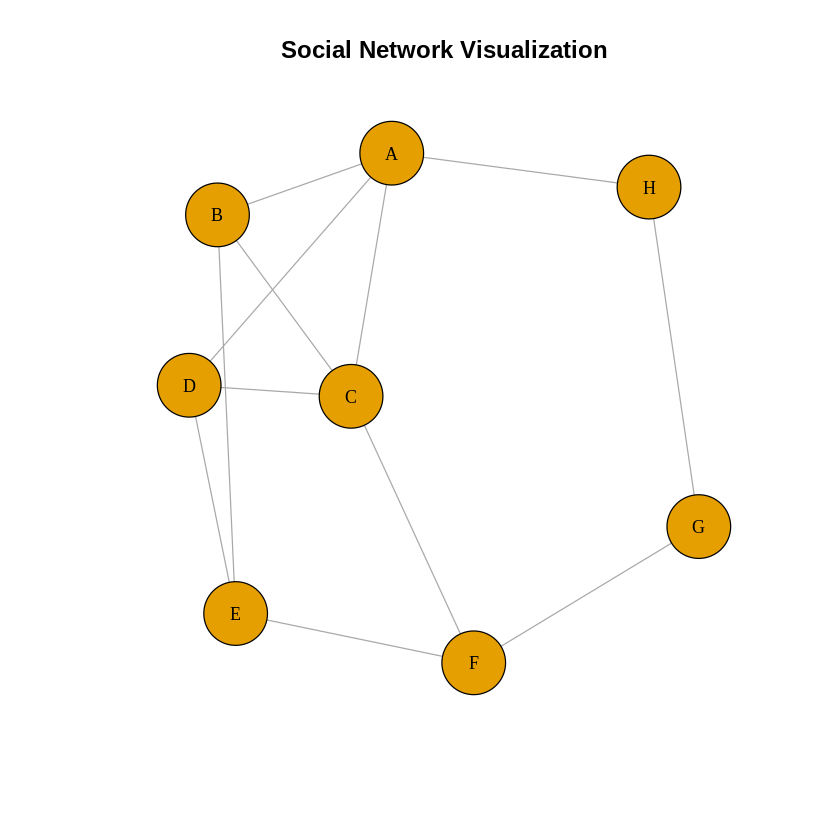

In [5]:
set.seed(123)
plot(
  g,
  layout = layout_with_fr(g),
  vertex.size = 25,
  vertex.label.cex = 0.9,
  vertex.label.color = "black",
  edge.arrow.size = 0.3,
  main = "Social Network Visualization"
)

In [6]:
degree_values <- degree(g)
degree_values

degree_rank <- sort(degree_values, decreasing = TRUE)
degree_rank

A B C D E F G H 
4 3 4 3 3 3 2 2

A C B D E F G H 
4 4 3 3 3 3 2 2

In [7]:
betweenness_values <- betweenness(g, normalized = TRUE)
sort(betweenness_values, decreasing = TRUE)

A          F          C          E          H          G          B 
0.22222222 0.19047619 0.14285714 0.09523810 0.07936508 0.06349206 0.05555556 
         D 
0.05555556

In [8]:
closeness_values <- closeness(g, normalized = TRUE)
sort(closeness_values, decreasing = TRUE)

A         C         F         B         D         E         H         G 
0.7000000 0.7000000 0.6363636 0.5833333 0.5833333 0.5833333 0.5384615 0.5000000

In [9]:
most_connected_node <- names(which.max(degree_values))
highest_degree <- max(degree_values)

cat("Most connected node:", most_connected_node, "\n")
cat("Highest degree:", highest_degree, "\n")

most_between_node <- names(which.max(betweenness_values))
cat("Highest betweenness node:", most_between_node, "\n")

Most connected node: A 
Highest degree: 4 
Highest betweenness node: A 


In [10]:
cat("Nodes:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", edge_density(g), "\n")
cat("Number of connected components:", components(g)$no, "\n")
cat("Average degree:", mean(degree_values), "\n")

Nodes: 8 
Edges: 12 
Density: 0.4285714 
Number of connected components: 1 
Average degree: 3 


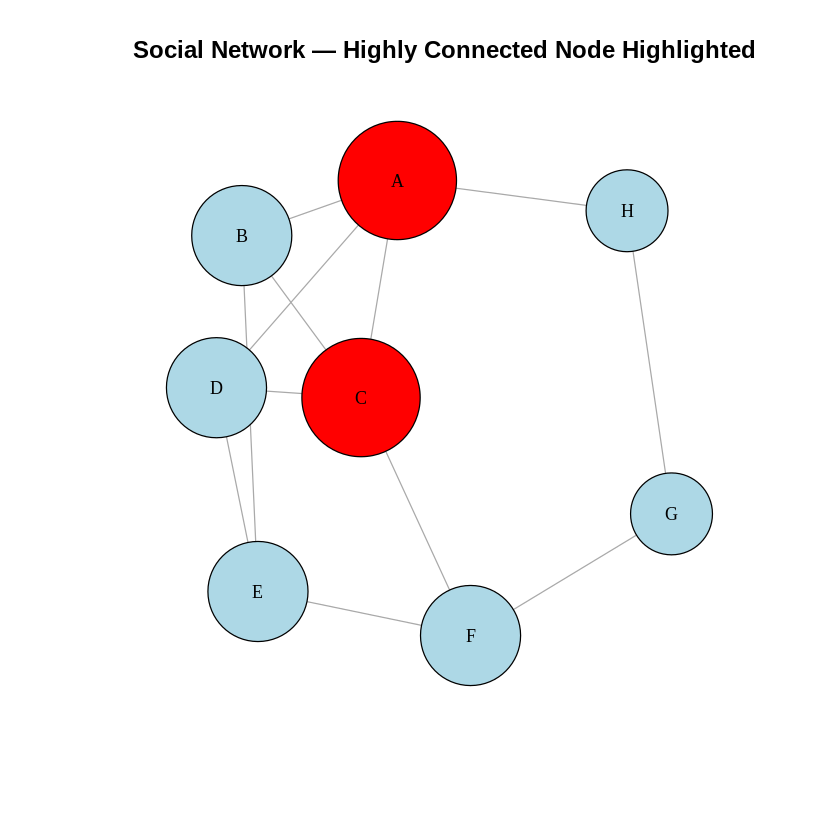

In [11]:
set.seed(123)
node_sizes <- 20 + 8 * degree_values
node_colors <- ifelse(degree_values == max(degree_values), "red", "lightblue")

plot(
  g,
  layout = layout_with_fr(g),
  vertex.size = node_sizes,
  vertex.color = node_colors,
  vertex.label.cex = 0.9,
  vertex.label.color = "black",
  edge.arrow.size = 0.3,
  main = "Social Network — Highly Connected Node Highlighted"
)

##  Interpretation

The network represents relationships between entities using nodes and edges. Node degree shows the number of direct connections, while betweenness and closeness provide additional measures of node importance. The node with the highest degree is the most directly connected entity in this example. Nodes with high betweenness can act as bridges between different parts of the network.

**Observation:** After executing the cells, use the displayed values to report the most connected node and the important network characteristics.

## Conclusion

Social Network Analysis was implemented using R and `igraph`. The relationship data was represented as a network, visualized, and analyzed using degree, betweenness, and closeness measures. The analysis helps identify highly connected and potentially influential nodes and provides an understanding of the overall network structure.

### Deliverables completed
- R source code
- Network dataset
- Network representation
- Network visualizations
- Network-analysis measures
- Interpretation and conclusion
